# LGAD Module simulator

## 1.- Goals of this notebook

* Understand all the aspects of the semi-empirical LGAD module response
* Visualize a typical signal
* Produce datasets containing the response of the LGAD + ETROC

Please download the libraries in order to start.

In [ ]:
!rm -rf InstrumentationSchool/
!git clone https://github.com/parbol/InstrumentationSchool.git
import sys
sys.path.append('/content/InstrumentationSchool')


Cloning into 'InstrumentationSchool'...
remote: Enumerating objects: 522, done.
remote: Counting objects: 100% (77/77), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 522 (delta 21), reused 57 (delta 14), pack-reused 445 (from 1)
Receiving objects: 100% (522/522), 138.12 KiB | 3.73 MiB/s, done.
Resolving deltas: 100% (218/218), done.


## 2.- Imports needed by the program

This program makes use of 4 modules:

* **LGADSimulator**: This module implements the LGAD semi-empirical model.
* **numpy**: This is the standard python package for numerical calculations.
* **matplotlib**: This is the standard python package for plotting data.
* **pandas**: This is one of the most popular packages to handle datasets.

In [ ]:
from LGADModuleSimulator.src.LGADSimulator import LGADSimulator
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## 3.- Have a look at the semi-empirical LGAD+ETROC simulator model

In the workbook of this exercise you will find a brief description of the model used to generate the LGAD+ETROC response, however it is important that you have a look at the code and understand how it works in detail.

### Model parameters

| Parameter | Definition |
| --- | --- |
| **Thickness** | This is just the thickness of the active area of the sensor. It is given in cm. |
| **Radius** | This is the distance at which this sensor is located with respect to the beam line. Take into account that in the case of CMS these sensors will be installed in the Endcap, in such a way that this distance determines the amount of radition that the sensor will be exposed to. It is given in cm. |
| **intLumi** | This is the integrated luminosity. Although in this exercise, radiation effects will not be considered, the degradation of the sensors due to radiation damage can be taken into account in this model. Given in inverse femtobarns.|
| **taur** | This is the time constant regulating the rise time of the LGAD+ETROC signal shape. It is given in nanoseconds. |
| **taud** | This is the time constant regulating the down time of the LGAD+ETROC signal shape. It is given in nanoseconds. |
| **clock** | This is the frecuency of the clock of the system. It is measured in GHz. |
| **treshold** | The treshold that will trigger the acquisition of an event. It is measured in fC. |
| **noiseLevel** | The RMS of the electronic noise in the signal. It is measure in fC. |
| **sigmaTDC** | This is the time resolution associated to the TDC conversor. |  

### Input to generate an event

Once a model is setup events can be generated. The events depend on 4 parameters:

| Parameter | Definition |
| --- | --- |
| **id** | The type of particle according to the PDG. |
| **p** | The momentum of the parcicle. It is given in GeV. |
| **angle** | The incidence angle. It is given in radian. |
| **t** | The actual entrance time to the sensor. It is given in nanoseconds. |

### Output of the event generator

For a given set of input variables the model generates two values:

|Parameter | Definition |
| --- | --- |
| **TOA** | The Time Of Arrival of the particle. It is given in ns. |
| **TOT** | The Time Over Threshold of the signal. It is given in ns. |

## 4.- Some questions before your continue (Please edit this cell and add your answers)

Q. How is the energy deposited in the sensor modeled?

A.

Q. What is the Gain of an LGAD sensor?

A.

Q. How is the gain behaving with respect to the radiation dose received?

A.

Q. Why is the energy deposited relevant in this system?

A.

Q. What is the parameter "signalTMax"?

A.

Q. What is the parameter "signalMax"?

A.


## 5.- Setting up two models with different parameters

In this section you will have to create two different models with the following suggested parameters:

| Parameter | Model 1 | Model 2 |
|---| --- | --- |
| thickness | 0.3     | 0.3     |
| radius    | 100.0   | 100.0   |
| intLumi   | 0.0     | 0.0     |
| taur      | 2.0     | 5.0     |
| taud      | 3.0     | 3.0     |
| clock     | 3.0     | 3.0     |
| threshold | 0.9525  | 0.9525  |
| noiseLevel| 0.2750  | 0.2750  |
| sigmaTDC  | 0.010   | 0.010   |

In [ ]:

model1 = LGADSimulator(thickness=0.3, radius=1.0,
                        intLumi = 0.0, taur = 2.5,
                        taud=4.0, clock=3.0,
                        threshold=0.9525, noiseLevel=0.2750, sigmaTDC=0.010)

model2 = LGADSimulator(thickness=0.3, radius=1.0,
                        intLumi = 0.0, taur = 3.0,
                        taud=8.0, clock=3.0,
                        threshold=0.9525, noiseLevel=0.2750, sigmaTDC=0.010)

## 6.- Draw one event for each model

Generate one event with each of the generators and draw the signal shapes and the tresholds. In order to do this, write a function that takes as input: a matplotlib axis, the model, the id of the particle (choose 121), the momentum in GeV, the angle, the t, and the color. Then call the function for the two models and different colors.

In [ ]:
def drawEvent(ax, model, id, p, angle, t, color):
    toa, tot, charge = model.getResponse(id, p, angle, t)
    if tot == -1:
        print('No signal detected')
        return
    n = int(20.0 * tot/model.clock)
    a = np.linspace(0, toa + 3.0*tot, n)
    ax.plot(a, charge*model.signalpdf(a), color = color)
    ax.axvline(x = toa, color = color, linestyle='dashed')
    ax.axvline(x = tot, color = color, linestyle='dashed')
    ax.axhline(y = model.threshold, color = color, linestyle='dashed')
    ax.set_xlabel('Time [ns]')
    ax.set_ylabel('Charge [fC]')


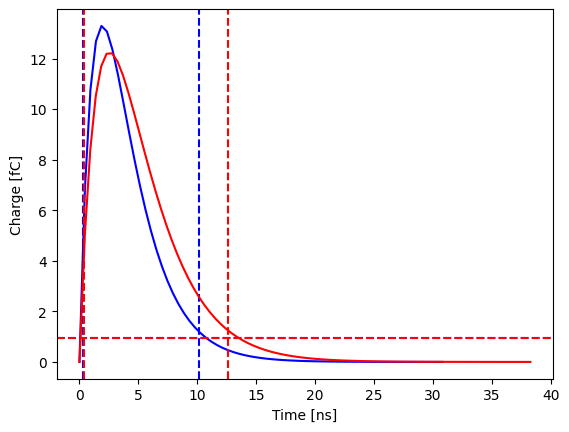

In [ ]:
fig, ax = plt.subplots()
drawEvent(ax, model1, 121, 10, 0, 0, 'b')
drawEvent(ax, model2, 121, 10, 0, 0, 'r')


## 7.- Generate a 2K events dataset per model

Write a code to produce a 2K dataset for each of the models. In order to do this, first make a function that takes as input the model, the number of events, and the output file name. This function will fill a dictionary with the 'id', the momentum 'p', angle 'phi', time 't', toat-t, 'toat', and tot 'tot', then we will convert the dictionary into a panda dataset and store it in parquet format. You will also need to assume some distributions for the generated particles. For that, just use the suggestion you are given.

In [ ]:
def produceDataset(model, number, filename):

    events = dict()
    events['id'] = []
    events['p'] = []
    events['phi'] = []
    events['t'] = []
    #We will store the difference between the TOA and t
    events['toat'] = []
    events['tot'] = []

    eventCounter = 0
    while eventCounter < number:
        id = 121
        p = np.random.uniform(1.0, 20) #GeV
        phi = np.random.normal(0, np.pi/12.0)
        if abs(phi) > np.pi/4.0:
            continue
        t = np.random.uniform(1, 5) #ns
        toa, tot, charge = model.getResponse(id, p, phi, t)
        if charge == -1 or abs(toa)>100.0 or abs(tot)>100.0:
            continue
        events['id'].append(id)
        events['p'].append(p)
        events['phi'].append(phi)
        events['t'].append(t)
        events['toat'].append(toa-t)
        events['tot'].append(tot)
        eventCounter = eventCounter + 1

    df = pd.DataFrame(events)
    df.to_parquet(filename)

In [ ]:
produceDataset(model1, 2000, 'model1.parquet')
produceDataset(model2, 2000, 'model2.parquet')

## 8.- Read and visualize the datasets

Open the parquet files you just generated and make a plot with the distribution of p, phi, t, toa, tot, and toa - t vs. tot, for the two datasets you generated.

In [ ]:
def makePlots(axs, dataname1, dataname2):

  data1 = pd.read_parquet(dataname1).to_numpy()
  data2 = pd.read_parquet(dataname2).to_numpy()

  axs[0][0].hist(data1[:,1], bins=50)
  axs[0][0].hist(data2[:,1], bins=50)
  axs[0][0].set_xlabel('p [GeV]')

  axs[0][1].hist(data1[:,2], bins=50)
  axs[0][1].hist(data2[:,2], bins=50)
  axs[0][1].set_xlabel('phi')

  axs[0][2].hist(data1[:,3], bins=50)
  axs[0][2].hist(data2[:,3], bins=50)
  axs[0][2].set_xlabel('t [ns]')

  axs[1][0].hist(data1[:,4]+data1[:,3], bins=50, range=(0, 6))
  axs[1][0].hist(data2[:,4]+data2[:,3], bins=50, range=(0, 6))
  axs[1][0].set_xlabel('toa [ns]')

  axs[1][1].hist(data1[:,5], bins=50, range=(5, 25))
  axs[1][1].hist(data2[:,5], bins=50, range=(5, 25))
  axs[1][1].set_xlabel('tot [ns]')

  axs[1][2].hist(data1[:,4], bins=50, range=(0,0.5))
  axs[1][2].hist(data2[:,4], bins=50, range=(0,0.5))
  axs[1][2].set_xlabel('toa - t [ns]')


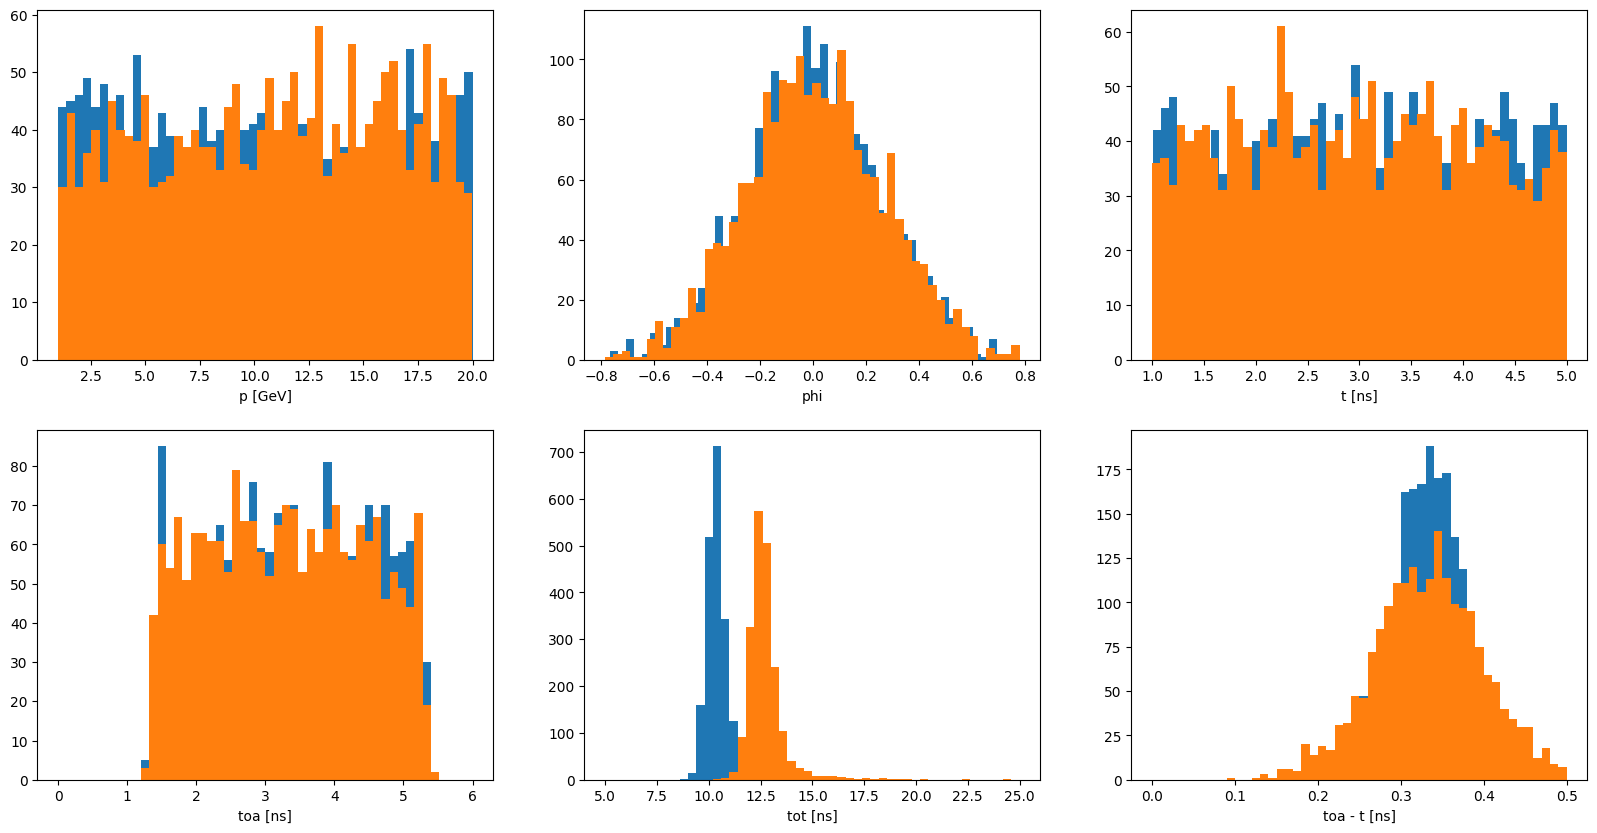

In [ ]:
#Figure
fig, axs = plt.subplots(2, 3, figsize=(20,10))

makePlots(axs, 'model1.parquet', 'model2.parquet')

